# Simulation Network Properties and Viral Emergence

Generates **Figure 4** (6 panels), **Figure S-NetworkMetrics** (10 panels), supplementary all-states versions, **S-PosteriorScatter**, and **S-RiskMap**.

**Data sources:**
- Panels A, B: Pool-based alternative origins (579 counties, 16 states, high/low connectivity tiers)
- Panels C, D, E, F + S-NetworkMetrics: All-county origins (2,501 counties, 48 states, 1,000 network realizations)
- S-PosteriorScatter: ABC-SMC accepted particles (75 parameter sets)
- S-RiskMap: All-county establishment probabilities (continuous scale)

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as sp_stats
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PROJ_ROOT = Path('../..').resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
PAPER_DIR = PROJ_ROOT / 'paper'
SIM_DIR = PROJ_ROOT / 'analysis' / 'simulations'
SCENARIO_DIR = SIM_DIR / 'outputs' / 'scenarios'
FIG_DIR = FINAL_DIR / 'figures'
LEGACY_FIG_DIR = PAPER_DIR / 'figures'

OUTBREAK_STATES = ['TX', 'CA', 'ID', 'IA', 'NM', 'KS', 'SD', 'CO',
                   'OH', 'NC', 'MI', 'MN', 'WY', 'OK', 'NE', 'UT']

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

STATE_COLORS = {
    'CA': '#e41a1c', 'IA': '#377eb8', 'TX': '#ff7f00', 'ID': '#4daf4a',
    'MN': '#984ea3', 'NM': '#a65628', 'CO': '#f781bf', 'KS': '#999999',
    'UT': '#66c2a5', 'SD': '#8da0cb', 'OH': '#e78ac3', 'MI': '#a6d854',
    'OK': '#ffd92f', 'NE': '#e5c494', 'NC': '#b3b3b3', 'WY': '#636363',
}

EPICENTER_COUNTIES = {
    48069: ('Castro', 'TX', '#d62728', '*', 250),
    48341: ('Moore', 'TX', '#ff7f00', 's', 120),
    48117: ('Deaf Smith', 'TX', '#2ca02c', 'D', 100),
    35009: ('Curry', 'NM', '#17becf', '^', 100),
    37183: ('Wake', 'NC', '#7f7f7f', 'v', 100),
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Pool-based data (Panels A, B): 579 counties, 16 states, high/low tiers ──
pool_data = pd.read_csv(LEGACY_FIG_DIR / 'county_establishment_new.csv')
print(f'Pool data: {len(pool_data)} counties, {pool_data.seed_state.nunique()} states')

# ── All-county data (Panels C, D, E, F + S_NetworkMetrics): 2,504 counties ──
# Network metrics file has 2,501; scenario_summary has all 2,504
allcounty = pd.read_csv(LEGACY_FIG_DIR / 'all_county_origins' / 'seed_county_network_metrics.csv')
scenario_all = pd.read_csv(LEGACY_FIG_DIR / 'all_county_origins' / 'scenario_summary.csv')
scenario_all['pct_establishment_3'] = 100 - scenario_all['pct_leq_2_states']

# Add the 3 counties missing from network metrics (100% dieout, no connections)
missing_fips = set(scenario_all['seed_county']) - set(allcounty['seed_county'])
if missing_fips:
    missing_rows = scenario_all[scenario_all['seed_county'].isin(missing_fips)][['seed_county', 'seed_state']].copy()
    missing_rows['pct_establishment_3'] = 0.0
    missing_rows['pct_dieout'] = 100.0
    missing_rows['pct_establishment_5'] = 0.0
    missing_rows['pct_establishment_10'] = 0.0
    for col in allcounty.columns:
        if col not in missing_rows.columns:
            missing_rows[col] = 0.0
    allcounty = pd.concat([allcounty, missing_rows], ignore_index=True)
    print(f'Added {len(missing_fips)} counties with 100% dieout: {missing_fips}')

# Counties with out_degree=0 have undefined temporal reach; fill with 0 (can't reach anyone)
n_filled = allcounty['temporal_reach_3hop_30d'].isna().sum()
if n_filled > 0:
    allcounty['temporal_reach_3hop_30d'] = allcounty['temporal_reach_3hop_30d'].fillna(0)
    print(f'Filled {n_filled} NaN temporal_reach_3hop_30d values with 0 (out_degree=0 counties)')

print(f'All-county data: {len(allcounty)} counties, {allcounty.seed_state.nunique()} states')

# ── Pool: merge with network metrics for Panels A, B ──
metric_cols = ['seed_county', 'out_degree', 'in_degree', 'temporal_reach_3hop_30d',
               'temporal_pagerank', 'temporal_betweenness', 'pagerank', 'betweenness',
               'eigenvector', 'closeness', 'clustering', 'shipping_consistency', 'max_gap',
               'out_volume', 'in_volume']
pool_merged = pool_data.merge(allcounty[metric_cols], on='seed_county', how='inner')
print(f'Pool merged: {len(pool_merged)} counties')

# State-level aggregation (high-tier only, for Panel A)
high_tier = pool_merged[pool_merged['connectivity_tier'] == 'high']
state_agg = high_tier.groupby('seed_state').agg(
    mean_out_degree=('out_degree', 'mean'),
    mean_establishment=('pct_establishment_3', 'mean'),
    n_counties=('seed_county', 'count'),
).reset_index()

print(f'\nPanel A/B: {len(state_agg)} states, {len(high_tier)} high-tier counties')

# ── All-county: filter for outbreak states (Panel C) ──
allcounty_outbreak = allcounty[allcounty['seed_state'].isin(OUTBREAK_STATES)]
print(f'All-county (outbreak states): {len(allcounty_outbreak)} counties')
print(f'All-county (all states): {len(allcounty)} counties')

# Epicenter county check
print(f'\nEpicenter counties:')
for fips, (name, st, *_) in EPICENTER_COUNTIES.items():
    row = allcounty[allcounty['seed_county'] == fips]
    if len(row) > 0:
        print(f'  {name} ({st}): estab={row.pct_establishment_3.values[0]:.1f}%, '
              f'out_degree={row.out_degree.values[0]:.1f}')
    else:
        print(f'  {name} ({st}): NOT FOUND')

Pool data: 579 counties, 16 states
Added 3 counties with 100% dieout: {5131, 48137, 37019}
Filled 3 NaN temporal_reach_3hop_30d values with 0 (out_degree=0 counties)
All-county data: 2504 counties, 48 states
Pool merged: 579 counties

Panel A/B: 16 states, 277 high-tier counties
All-county (outbreak states): 1087 counties
All-county (all states): 2504 counties

Epicenter counties:
  Castro (TX): estab=99.8%, out_degree=125.0
  Moore (TX): estab=79.9%, out_degree=42.3
  Deaf Smith (TX): estab=99.9%, out_degree=201.5
  Curry (NM): estab=100.0%, out_degree=112.7
  Wake (NC): estab=0.0%, out_degree=0.5


## Figure 4: County Network Properties and Viral Emergence

Six panels showing the relationship between cattle movement network properties and viral Multi-state spread probability.

In [3]:
# ── Helper functions for scatter panels ──

def plot_scatter_with_epicenters(ax, data, xcol, ycol, xlabel, ylabel,
                                 exclude_zero_x=False, add_inset=True, 
                                 inset_x=0.58, inset_y=0.06, inset_width=0.40, inset_height=0.42,
                                 inset_fontsize=5,
                                 epicenter_exclude=None, state_col='seed_state',
                                 all_states=False):
    """Generic scatter of all counties colored by state, with epicenter overlays.
    Inset: 0-80th percentile of x-axis metric, with Spearman rho."""
    df = data.copy()
    if exclude_zero_x:
        df = df[df[xcol] > 0]

    # Determine which states to color
    if all_states:
        unique_states = sorted(df[state_col].unique())
        cmap = plt.cm.tab20
        colors = {st: cmap(i / max(len(unique_states), 1)) for i, st in enumerate(unique_states)}
    else:
        colors = STATE_COLORS

    # Background scatter (gray for non-colored states)
    colored_mask = df[state_col].isin(colors.keys())
    if not all_states and (~colored_mask).any():
        ax.scatter(df.loc[~colored_mask, xcol], df.loc[~colored_mask, ycol],
                   c='#DDDDDD', s=8, alpha=0.3, zorder=1)

    for st in sorted(colors.keys()):
        mask = df[state_col] == st
        if mask.any():
            ax.scatter(df.loc[mask, xcol], df.loc[mask, ycol],
                       c=colors[st], s=18, alpha=0.4, edgecolors='none', zorder=2)

    # Epicenter overlays
    for fips, (name, st, color, marker, ms) in EPICENTER_COUNTIES.items():
        if epicenter_exclude and fips in epicenter_exclude:
            continue
        row = df[df['seed_county'] == fips]
        if len(row) > 0:
            ax.scatter(row[xcol], row[ycol], c=color, marker=marker, s=ms,
                       edgecolors='black', linewidths=0.8, zorder=10)

    # Spearman (full dataset)
    valid = df[[xcol, ycol]].dropna()
    rho, pval = sp_stats.spearmanr(valid[xcol], valid[ycol])
    pstr = f'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
    ax.text(0.97, 0.75, f'Spearman ρ = {rho:.2f}\n{pstr}\nn = {len(valid)}',
            transform=ax.transAxes, fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(-5, 105)
    style_ax(ax)

    # Inset: 0-80th percentile of x-axis metric
    if add_inset:
        ax_in = ax.inset_axes([inset_x, inset_y, inset_width, inset_height])
        x_vals = df[xcol].dropna()
        p80 = np.percentile(x_vals, 80)
        dfi = df[df[xcol] <= p80]

        if not all_states:
            colored_mask_i = dfi[state_col].isin(colors.keys())
            if (~colored_mask_i).any():
                ax_in.scatter(dfi.loc[~colored_mask_i, xcol], dfi.loc[~colored_mask_i, ycol],
                              c='#DDDDDD', s=4, alpha=0.3, zorder=1)
        for st in sorted(colors.keys()):
            mask2 = dfi[state_col] == st
            if mask2.any():
                ax_in.scatter(dfi.loc[mask2, xcol], dfi.loc[mask2, ycol],
                              c=colors[st], s=8, alpha=0.6, edgecolors='none')

        valid_i = dfi[[xcol, ycol]].dropna()
        if len(valid_i) > 5:
            z = np.polyfit(valid_i[xcol], valid_i[ycol], 1)
            xline = np.linspace(valid_i[xcol].min(), valid_i[xcol].max(), 100)
            ax_in.plot(xline, np.polyval(z, xline), 'k-', lw=1, alpha=0.7)
            rho_i, pi = sp_stats.spearmanr(valid_i[xcol], valid_i[ycol])
            pstr_i = f'p < 0.001' if pi < 0.001 else f'p = {pi:.3f}'
            ax_in.text(0.05, 0.95, f'ρ = {rho_i:.2f}\n{pstr_i}\nn = {len(valid_i)}',
                       transform=ax_in.transAxes, fontsize=inset_fontsize, va='top', ha='left',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5))
        # increase fontsize of inset axes tick labels
        from matplotlib.ticker import MaxNLocator
        ax_in.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_in.tick_params(labelsize=inset_fontsize)

    return rho, pval

print('Helpers defined.')

Helpers defined.


Panel C: 42 counties with >=95% establishment across 7 states


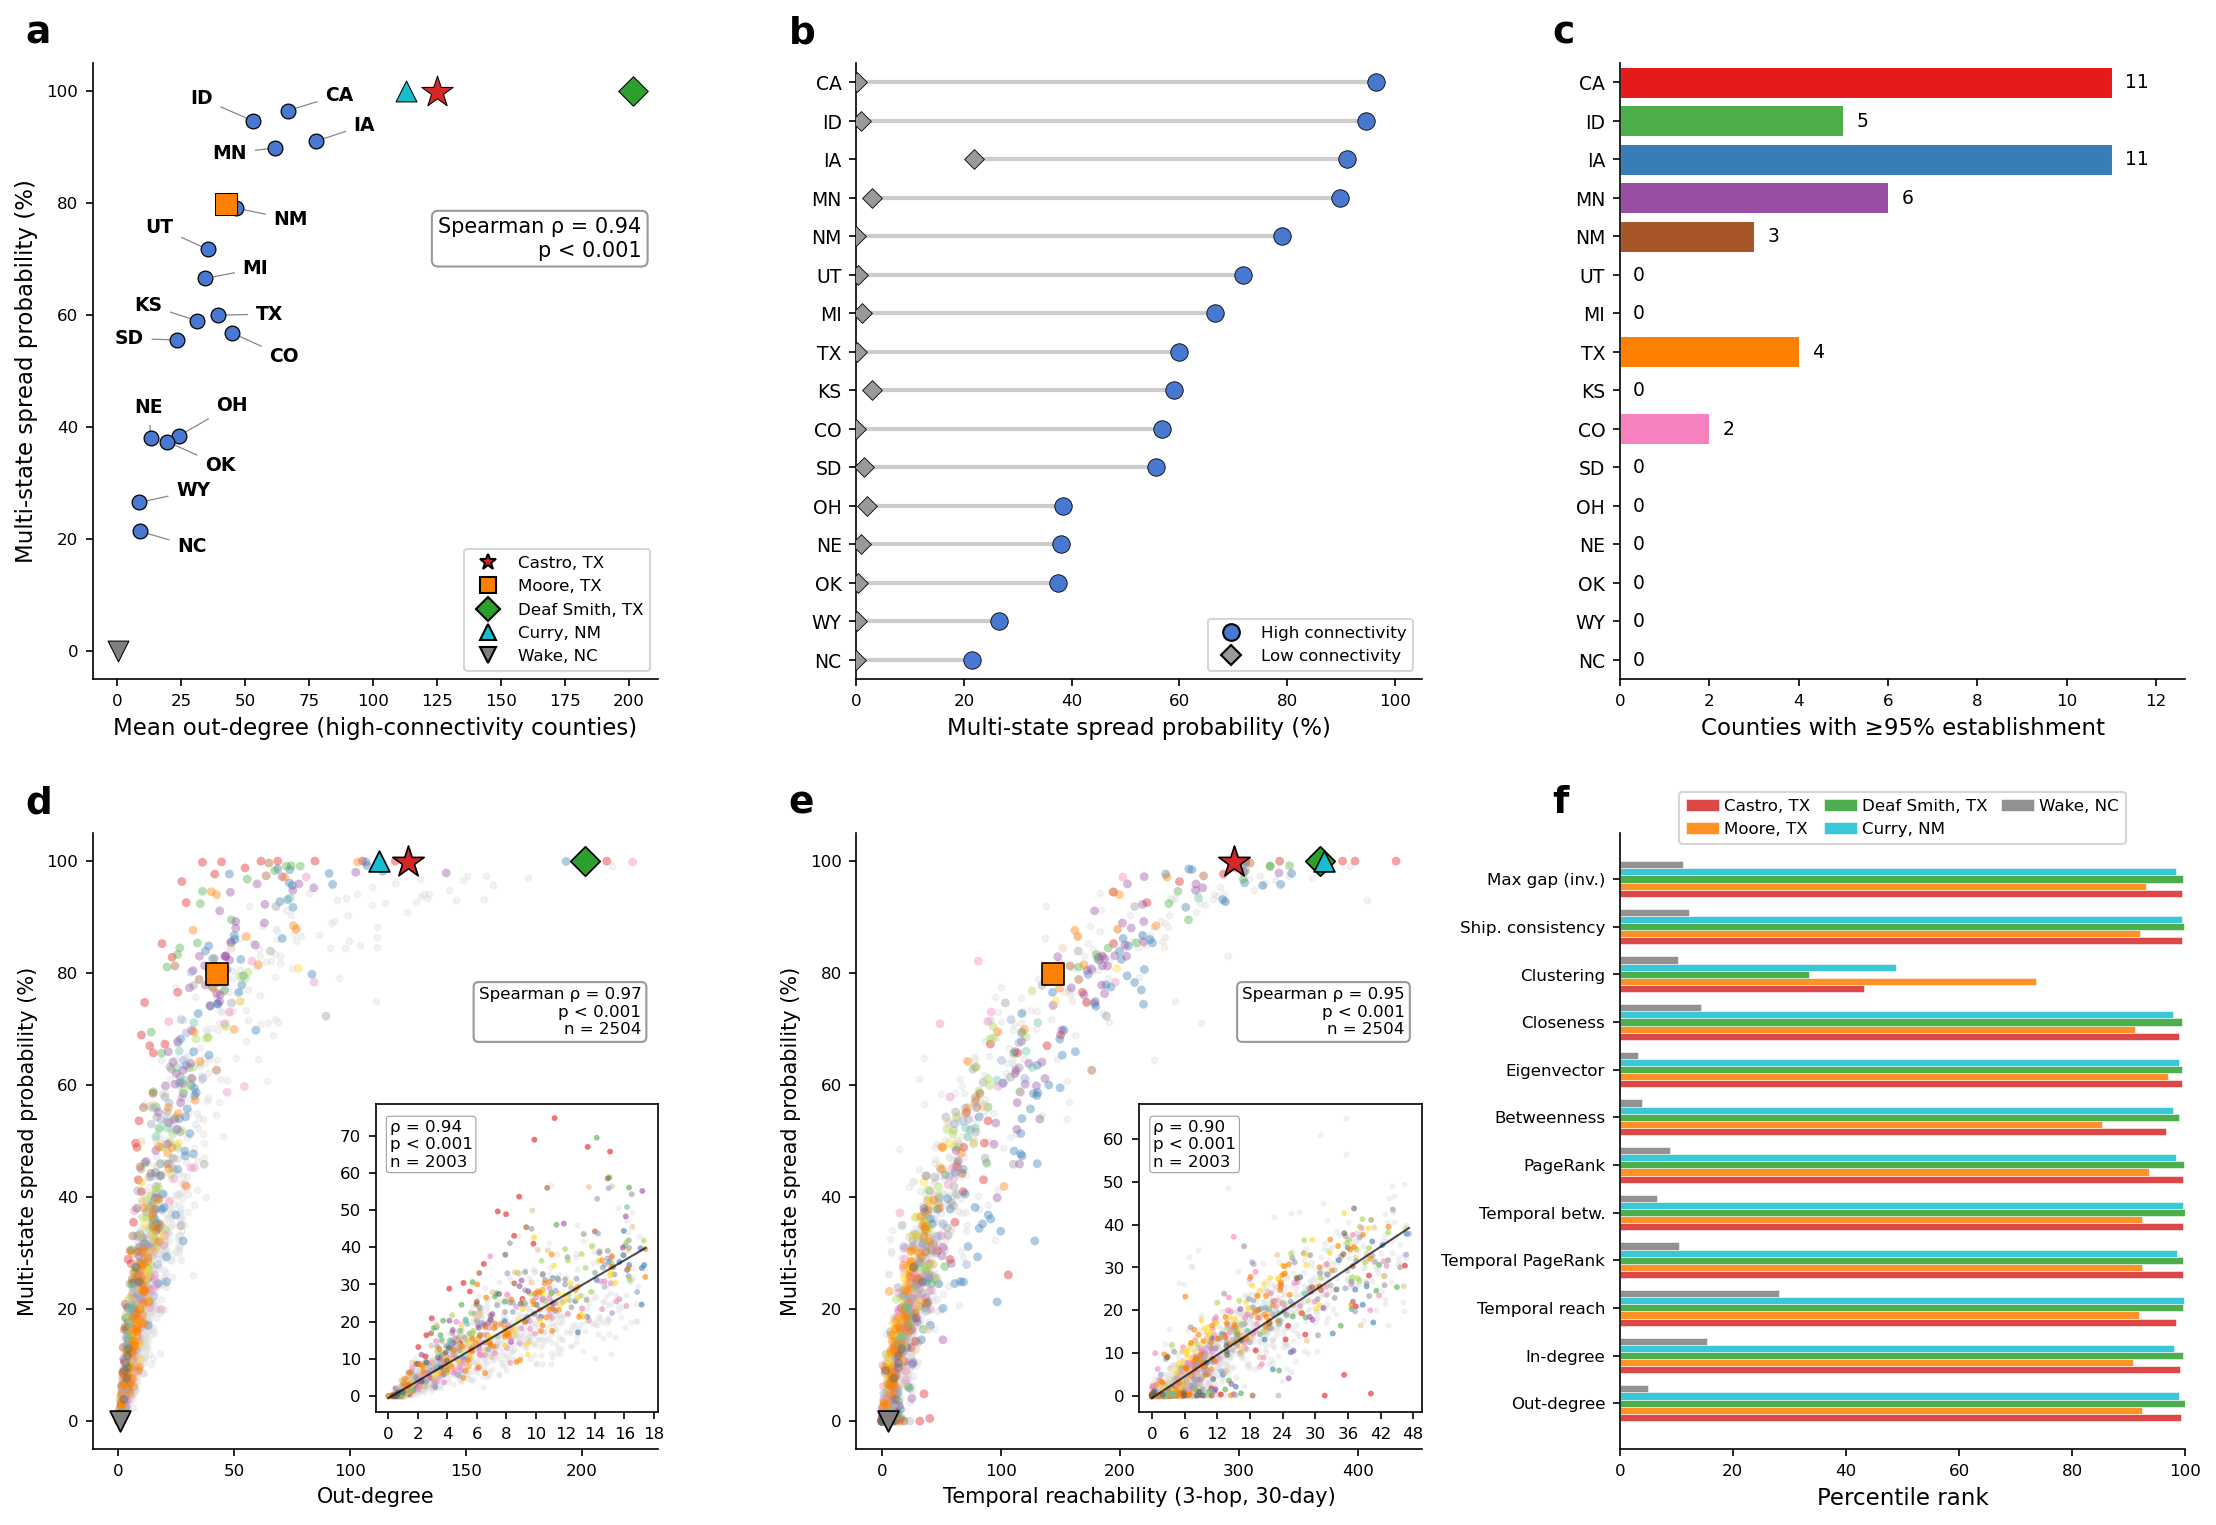

In [4]:
# ── Figure 4 ──
fig, axes = plt.subplots(2, 3, figsize=(18, 12),
                         gridspec_kw={'hspace': 0.25, 'wspace': 0.35})

# ────────────────────────────────────────────────────────────
# Panel A: State-level out-degree vs establishment (high-tier, POOL DATA)
# ────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(state_agg['mean_out_degree'], state_agg['mean_establishment'],
           c='#4878CF', s=50, edgecolors='black', linewidths=0.6, zorder=5)

rho_a, pval_a = sp_stats.spearmanr(state_agg['mean_out_degree'], state_agg['mean_establishment'])
pstr_a = f'p < 0.001' if pval_a < 0.001 else f'p = {pval_a:.3f}'
ax.text(0.97, 0.75, f'Spearman ρ = {rho_a:.2f}\n{pstr_a}',
        transform=ax.transAxes, fontsize=10, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

offsets = {
    'NC': (18, -10), 'WY': (18, 3),
    'NE': (-8, 12), 'OK': (18, -14), 'OH': (18, 12),
    'SD': (-30, -2), 'CO': (18, -14), 'KS': (-30, 5), 'TX': (18, -2),
    'MI': (18, 2), 'UT': (-30, 8),
    'NM': (18, -8),
    'MN': (-30, -5), 'IA': (18, 5),
    'ID': (-30, 8), 'CA': (18, 5),
}
for _, row in state_agg.iterrows():
    st = row['seed_state']
    dx, dy = offsets.get(st, (5, 5))
    ax.annotate(st, (row['mean_out_degree'], row['mean_establishment']),
                xytext=(dx, dy), textcoords='offset points', fontsize=9, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color='#888888', lw=0.6))

epic_handles = []
for fips, (name, st, color, marker, ms) in EPICENTER_COUNTIES.items():
    row = allcounty[allcounty['seed_county'] == fips]
    if len(row) > 0:
        ax.scatter(row['out_degree'], row['pct_establishment_3'],
                   c=color, marker=marker, s=ms, edgecolors='black',
                   linewidths=0.5, zorder=10)
        epic_handles.append(
            Line2D([0], [0], marker=marker, color='w', markerfacecolor=color,
                   markersize=8, markeredgecolor='black', label=f'{name}, {st}')
        )
ax.legend(handles=epic_handles, loc='lower right', fontsize=8)
ax.set_xlabel('Mean out-degree (high-connectivity counties)', fontsize=11)
ax.set_ylabel('Multi-state spread probability (%)', fontsize=11)
style_ax(ax)

# ────────────────────────────────────────────────────────────
# Panel B: Barbell plot (high vs low connectivity, POOL DATA)
# ────────────────────────────────────────────────────────────
ax = axes[0, 1]

tier_agg = pool_merged.groupby(['seed_state', 'connectivity_tier'])['pct_establishment_3'].mean().unstack(fill_value=0)
tier_agg = tier_agg.sort_values('high', ascending=True)

n_states_bc = len(tier_agg)
y_positions = np.arange(n_states_bc)
for i, st in enumerate(tier_agg.index):
    h_val = tier_agg.loc[st, 'high'] if 'high' in tier_agg.columns else 0
    l_val = tier_agg.loc[st, 'low'] if 'low' in tier_agg.columns else 0
    ax.plot([l_val, h_val], [i, i], '-', color='#CCCCCC', lw=2, zorder=1)
    ax.scatter(h_val, i, c='#4878CF', s=70, edgecolors='black', linewidths=0.4, zorder=5)
    ax.scatter(l_val, i, c='#999999', marker='D', s=45, edgecolors='black', linewidths=0.4, zorder=5)

ax.set_yticks(y_positions)
ax.set_yticklabels(tier_agg.index, fontsize=9)
ax.set_ylim(-0.5, n_states_bc - 0.5)
ax.set_xlim(0, 105)
ax.set_xlabel('Multi-state spread probability (%)', fontsize=11)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4878CF', markersize=8,
           markeredgecolor='black', label='High connectivity'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#999999', markersize=7,
           markeredgecolor='black', label='Low connectivity'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
style_ax(ax)

# ────────────────────────────────────────────────────────────
# Panel C: Counties >=95% establishment (ALL 16 states, ordered as Panel B)
# ────────────────────────────────────────────────────────────
ax = axes[0, 2]

high95_counts = allcounty_outbreak[allcounty_outbreak['pct_establishment_3'] >= 95].groupby('seed_state').size()
high95 = pd.DataFrame({'count': [high95_counts.get(st, 0) for st in tier_agg.index]},
                       index=tier_agg.index)

bars = ax.barh(range(n_states_bc), high95['count'],
               color=[STATE_COLORS.get(s, '#888') for s in high95.index],
               edgecolor='white', linewidth=0.5)
ax.set_yticks(range(n_states_bc))
ax.set_yticklabels(high95.index, fontsize=9)
ax.set_ylim(-0.5, n_states_bc - 0.5)
ax.set_xlabel('Counties with ≥95% establishment', fontsize=11)

for i, (st, row) in enumerate(high95.iterrows()):
    ax.text(max(row['count'], 0) + 0.3, i, str(int(row['count'])), va='center', fontsize=9)

ax.set_xlim(0, high95['count'].max() * 1.15 if high95['count'].max() > 0 else 10)
style_ax(ax)

print(f'Panel C: {high95["count"].sum()} counties with >=95% establishment across {(high95["count"] > 0).sum()} states')

# ────────────────────────────────────────────────────────────
# Panel D: County out-degree vs establishment (ALL-COUNTY DATA)
# ────────────────────────────────────────────────────────────
ax = axes[1, 0]
plot_scatter_with_epicenters(ax, allcounty, 'out_degree', 'pct_establishment_3',
                             'Out-degree', 'Multi-state spread probability (%)',
                             add_inset=True, inset_x=0.5, inset_y=0.06, inset_width=0.5, inset_height=0.5, inset_fontsize=8)

# ────────────────────────────────────────────────────────────
# Panel E: Temporal reachability vs establishment (ALL-COUNTY DATA, all 2504)
# ────────────────────────────────────────────────────────────
ax = axes[1, 1]
plot_scatter_with_epicenters(ax, allcounty,
                             'temporal_reach_3hop_30d', 'pct_establishment_3',
                             'Temporal reachability (3-hop, 30-day)',
                             'Multi-state spread probability (%)',
                             add_inset=True, inset_x=0.5, inset_y=0.06, inset_width=0.5, inset_height=0.5, inset_fontsize=8)

# ────────────────────────────────────────────────────────────
# Panel F: Epicenter county percentile ranks (ALL-COUNTY DATA)
# ────────────────────────────────────────────────────────────
ax = axes[1, 2]

rank_metrics = ['out_degree', 'in_degree', 'temporal_reach_3hop_30d',
                'temporal_pagerank', 'temporal_betweenness',
                'pagerank', 'betweenness', 'eigenvector', 'closeness',
                'clustering', 'shipping_consistency', 'max_gap']

pctile_df = pd.DataFrame()
for m in rank_metrics:
    vals = allcounty[m].dropna()
    if m == 'max_gap':
        pctile_df[m] = allcounty[m].apply(
            lambda x: sp_stats.percentileofscore(vals, x, kind='rank') if pd.notna(x) else np.nan)
        pctile_df[m] = 100 - pctile_df[m]
    else:
        pctile_df[m] = allcounty[m].apply(
            lambda x: sp_stats.percentileofscore(vals, x, kind='rank') if pd.notna(x) else np.nan)

pctile_df['seed_county'] = allcounty['seed_county'].values

epic_fips = list(EPICENTER_COUNTIES.keys())
epic_data = pctile_df[pctile_df['seed_county'].isin(epic_fips)].set_index('seed_county')

n_metrics = len(rank_metrics)
n_counties = len(epic_fips)
bar_height = 0.15
y_base = np.arange(n_metrics)

for i, fips in enumerate(epic_fips):
    name, st, color, marker, ms = EPICENTER_COUNTIES[fips]
    if fips in epic_data.index:
        vals = [epic_data.loc[fips, m] if pd.notna(epic_data.loc[fips, m]) else 0 for m in rank_metrics]
        ax.barh(y_base + i * bar_height, vals, height=bar_height,
                color=color, alpha=0.85, label=f'{name}, {st}', edgecolor='white', linewidth=0.3)

ax.set_yticks(y_base + bar_height * (n_counties - 1) / 2)

metric_labels = {
    'out_degree': 'Out-degree', 'in_degree': 'In-degree',
    'temporal_reach_3hop_30d': 'Temporal reach', 'temporal_pagerank': 'Temporal PageRank',
    'temporal_betweenness': 'Temporal betw.', 'pagerank': 'PageRank',
    'betweenness': 'Betweenness', 'eigenvector': 'Eigenvector',
    'closeness': 'Closeness', 'clustering': 'Clustering',
    'shipping_consistency': 'Ship. consistency', 'max_gap': 'Max gap (inv.)',
}
ax.set_yticklabels([metric_labels.get(m, m) for m in rank_metrics], fontsize=8)
ax.set_xlabel('Percentile rank', fontsize=11)
ax.set_xlim(0, 100)
ax.legend(fontsize=8, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.08),
          columnspacing=0.8, handletextpad=0.3)
style_ax(ax)

# ── Panel labels ──
for i, (ax_i, label) in enumerate(zip(axes.flat, 'abcdef')):
    ax_i.text(-0.12, 1.02, label, transform=ax_i.transAxes,
              fontsize=18, fontweight='bold', va='bottom')

# fig.savefig(FIG_DIR / 'fig_4.png')
# fig.savefig(FIG_DIR / 'fig_4.pdf')
# print('Figure 4 saved.')
plt.show()

## Figure S-NetworkMetrics: Additional Network Metrics vs Establishment

10 panels showing network metrics not included in Figure 4 main panels. Uses all-county data (2,501 counties, 48 states).

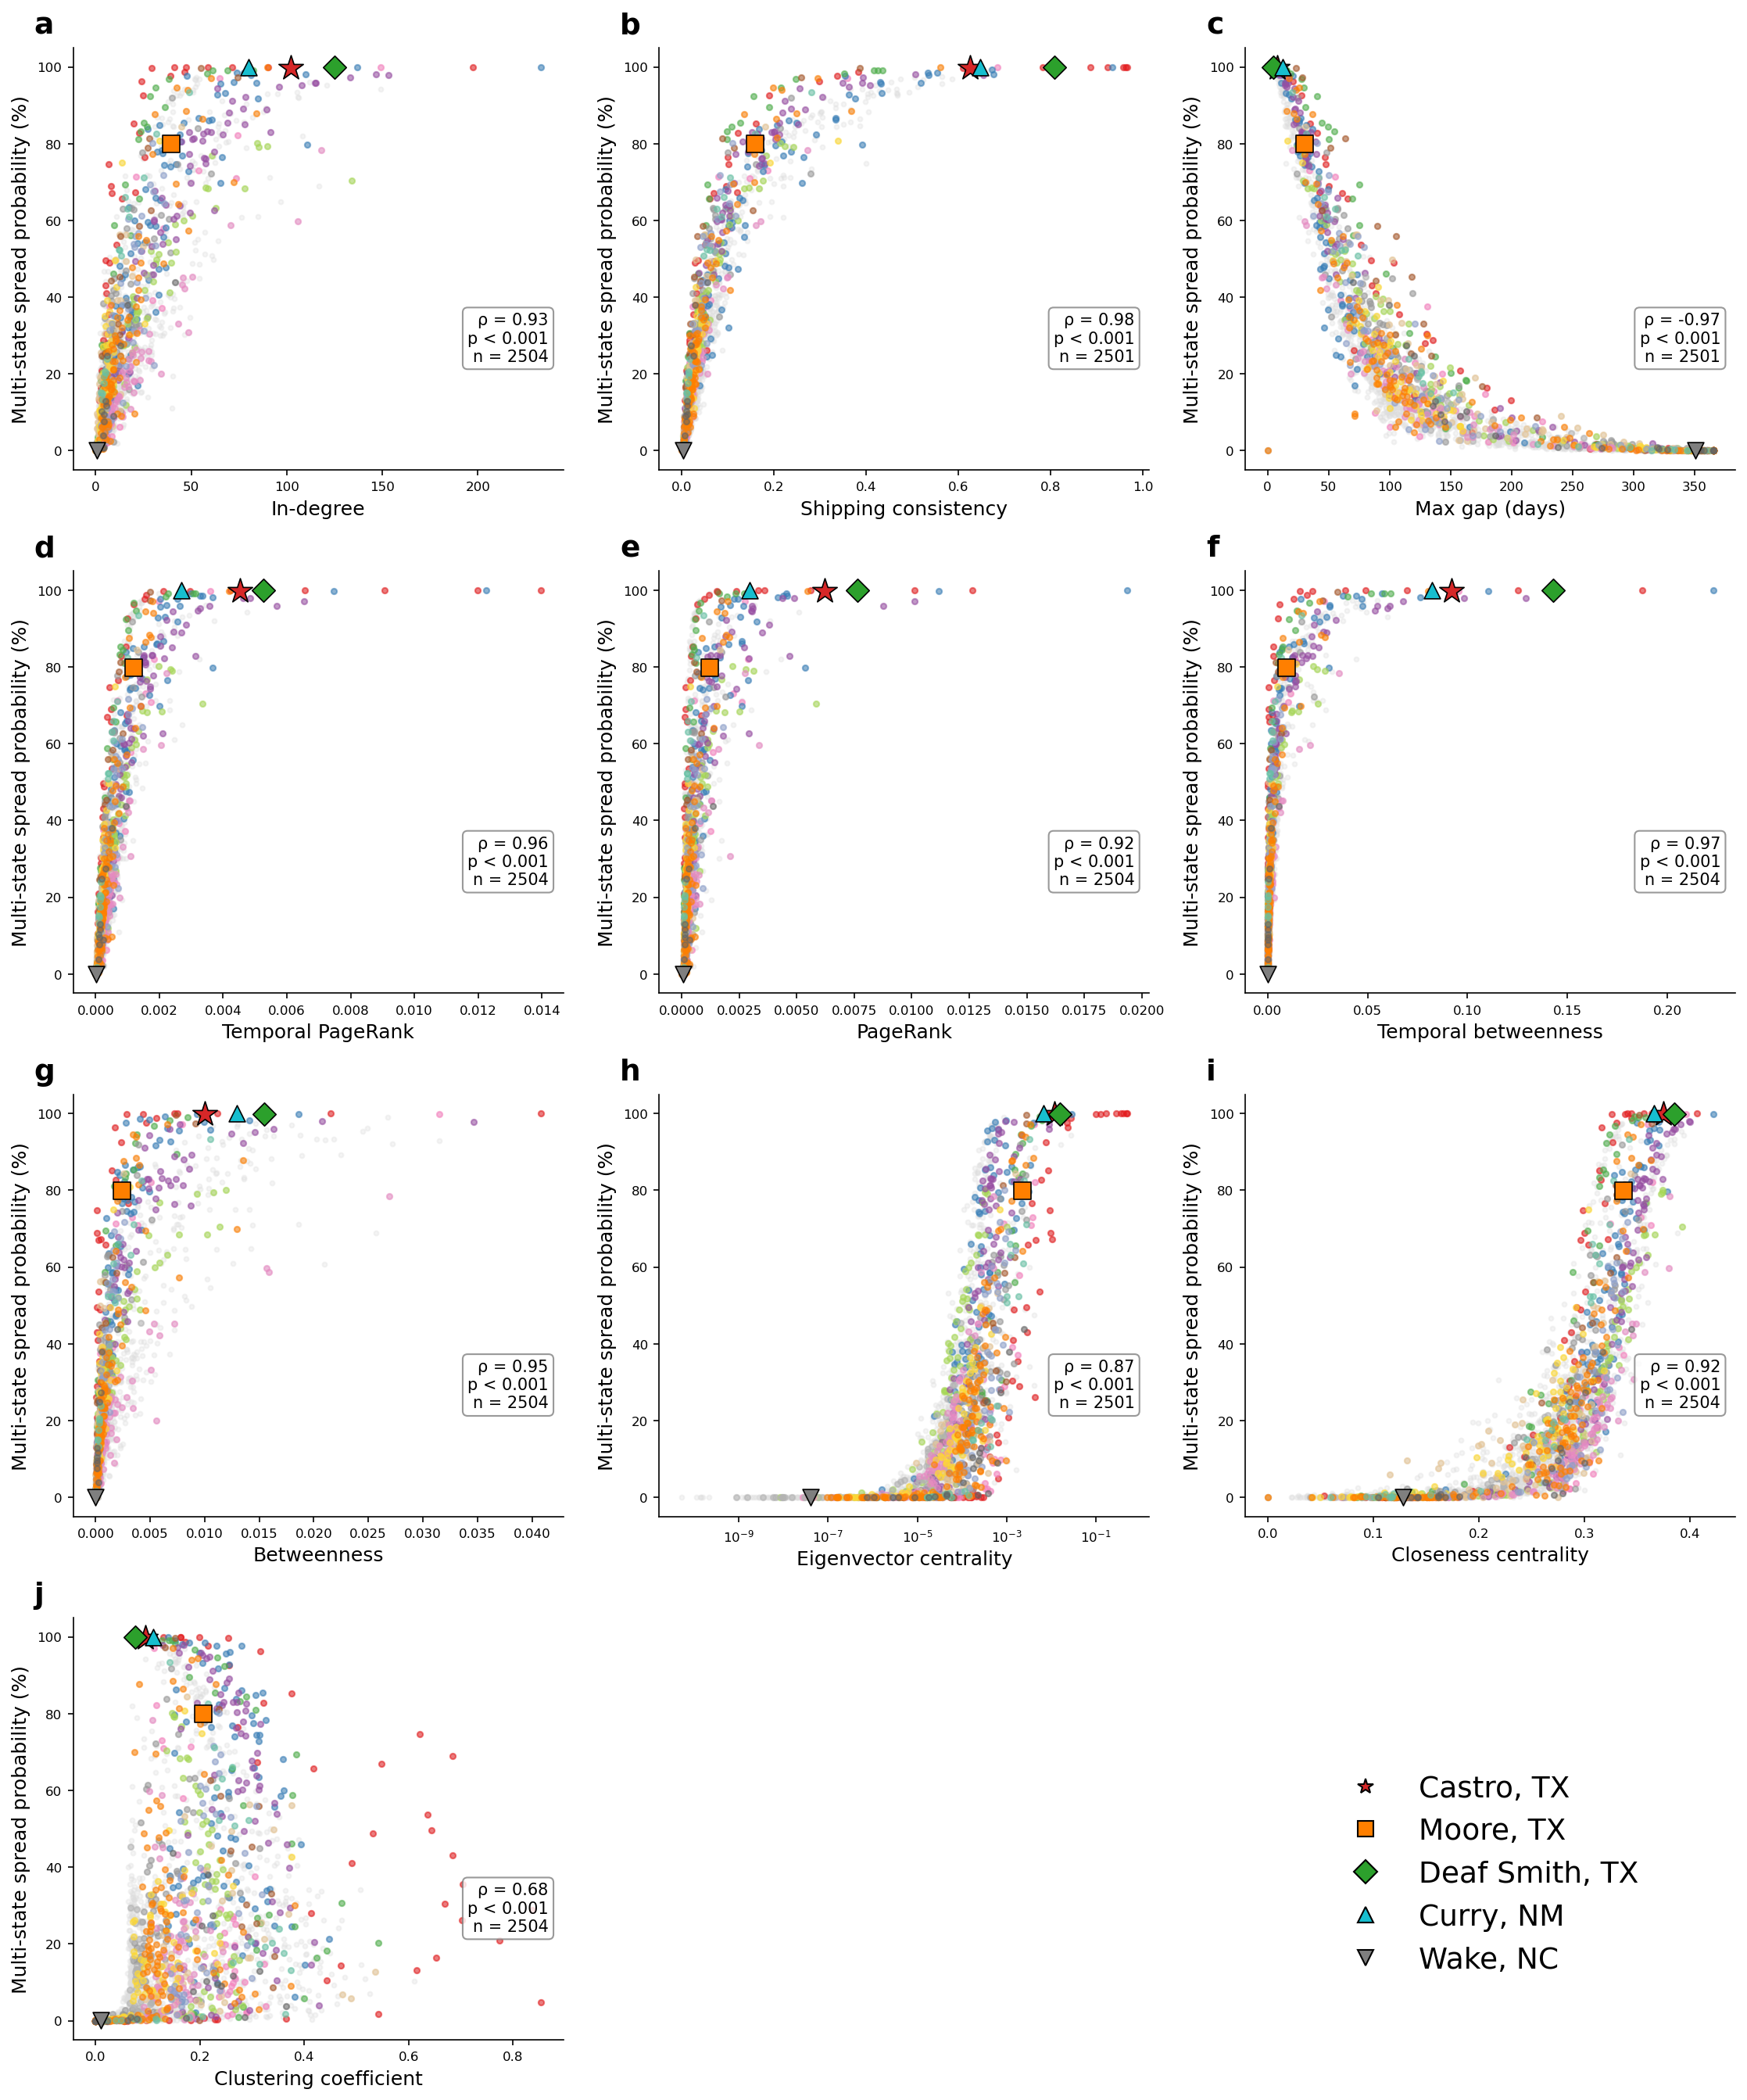

In [5]:
# ── Figure S-NetworkMetrics (10 panels, ALL-COUNTY DATA) ──

supp_metrics = [
    ('in_degree', 'In-degree', False),
    ('shipping_consistency', 'Shipping consistency', False),
    ('max_gap', 'Max gap (days)', False),
    ('temporal_pagerank', 'Temporal PageRank', False),
    ('pagerank', 'PageRank', False),
    ('temporal_betweenness', 'Temporal betweenness', False),
    ('betweenness', 'Betweenness', False),
    ('eigenvector', 'Eigenvector centrality', True),
    ('closeness', 'Closeness centrality', False),
    ('clustering', 'Clustering coefficient', False),
]

fig_sn, axes_sn = plt.subplots(4, 3, figsize=(15, 18))

for idx, (metric, label, use_log) in enumerate(supp_metrics):
    row, col = divmod(idx, 3)
    ax = axes_sn[row, col]

    df_plot = allcounty.copy()
    if use_log:
        df_plot = df_plot[df_plot[metric] > 0]

    # Gray background scatter
    ax.scatter(df_plot[metric], df_plot['pct_establishment_3'],
               c='#DDDDDD', s=8, alpha=0.3, zorder=1)

    # State-colored overlay (16 outbreak states only)
    for st in sorted(STATE_COLORS.keys()):
        mask = df_plot['seed_state'] == st
        if mask.any():
            ax.scatter(df_plot.loc[mask, metric], df_plot.loc[mask, 'pct_establishment_3'],
                       c=STATE_COLORS[st], s=12, alpha=0.55, zorder=3)

    # Epicenter overlays
    for fips, (name, st, color, marker, ms) in EPICENTER_COUNTIES.items():
        row_data = df_plot[df_plot['seed_county'] == fips]
        if len(row_data) > 0:
            ax.scatter(row_data[metric], row_data['pct_establishment_3'],
                       c=color, marker=marker, s=ms, edgecolors='black',
                       linewidths=0.8, zorder=10)

    # Spearman
    valid = df_plot[[metric, 'pct_establishment_3']].dropna()
    rho_s, pval_s = sp_stats.spearmanr(valid[metric], valid['pct_establishment_3'])
    pstr_s = f'p < 0.001' if pval_s < 0.001 else f'p = {pval_s:.3f}'
    ax.text(0.97, 0.25, f'ρ = {rho_s:.2f}\n{pstr_s}\nn = {len(valid)}',
            transform=ax.transAxes, fontsize=10, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

    if use_log:
        ax.set_xscale('log')
    ax.set_xlabel(label)
    ax.set_ylabel('Multi-state spread probability (%)')
    ax.set_ylim(-5, 105)
    style_ax(ax)

    panel_label = chr(ord('a') + idx)
    ax.text(-0.08, 1.02, panel_label, transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='bottom')
    
    # increase fontsize for labels
    ax.tick_params(labelsize=8)
    ax.xaxis.label.set_fontsize(12)
    ax.yaxis.label.set_fontsize(12)

# Hide unused panels
for empty_idx in [(3, 1), (3, 2)]:
    axes_sn[empty_idx].set_visible(False)

legend_elements = [
    Line2D([0], [0], marker=marker, color='w', markerfacecolor=color,
           markersize=10, markeredgecolor='black', label=f'{name}, {st}')
    for fips, (name, st, color, marker, ms) in EPICENTER_COUNTIES.items()
]
fig_sn.legend(handles=legend_elements, loc='lower right', fontsize=18, bbox_to_anchor=(0.95, 0.05), frameon=False)

fig_sn.tight_layout()
# fig_sn.savefig(FIG_DIR / 'S_NetworkMetrics.png')
# fig_sn.savefig(FIG_DIR / 'S_NetworkMetrics.pdf')
# print(f'Figure S-NetworkMetrics saved. n = {len(allcounty)} counties.')
plt.show()

## Supplementary: All-48-States Barbell and Barplot

Analogous to Panels B and C of Figure 4, but showing all 48 contiguous states (not just the 16 with documented outbreaks). Derives connectivity tiers from out-degree quartiles within each state.

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_94592/1534770898.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  allcounty_tiered = allcounty.groupby('seed_state', group_keys=False).apply(assign_tiers)


States included: 48 (smallest: 3 counties in DE)
All-states supplement saved. 48 states in both panels
States with >=95% counties: 9
Non-outbreak states with >=95%:
  WI: 2 counties
  NY: 7 counties


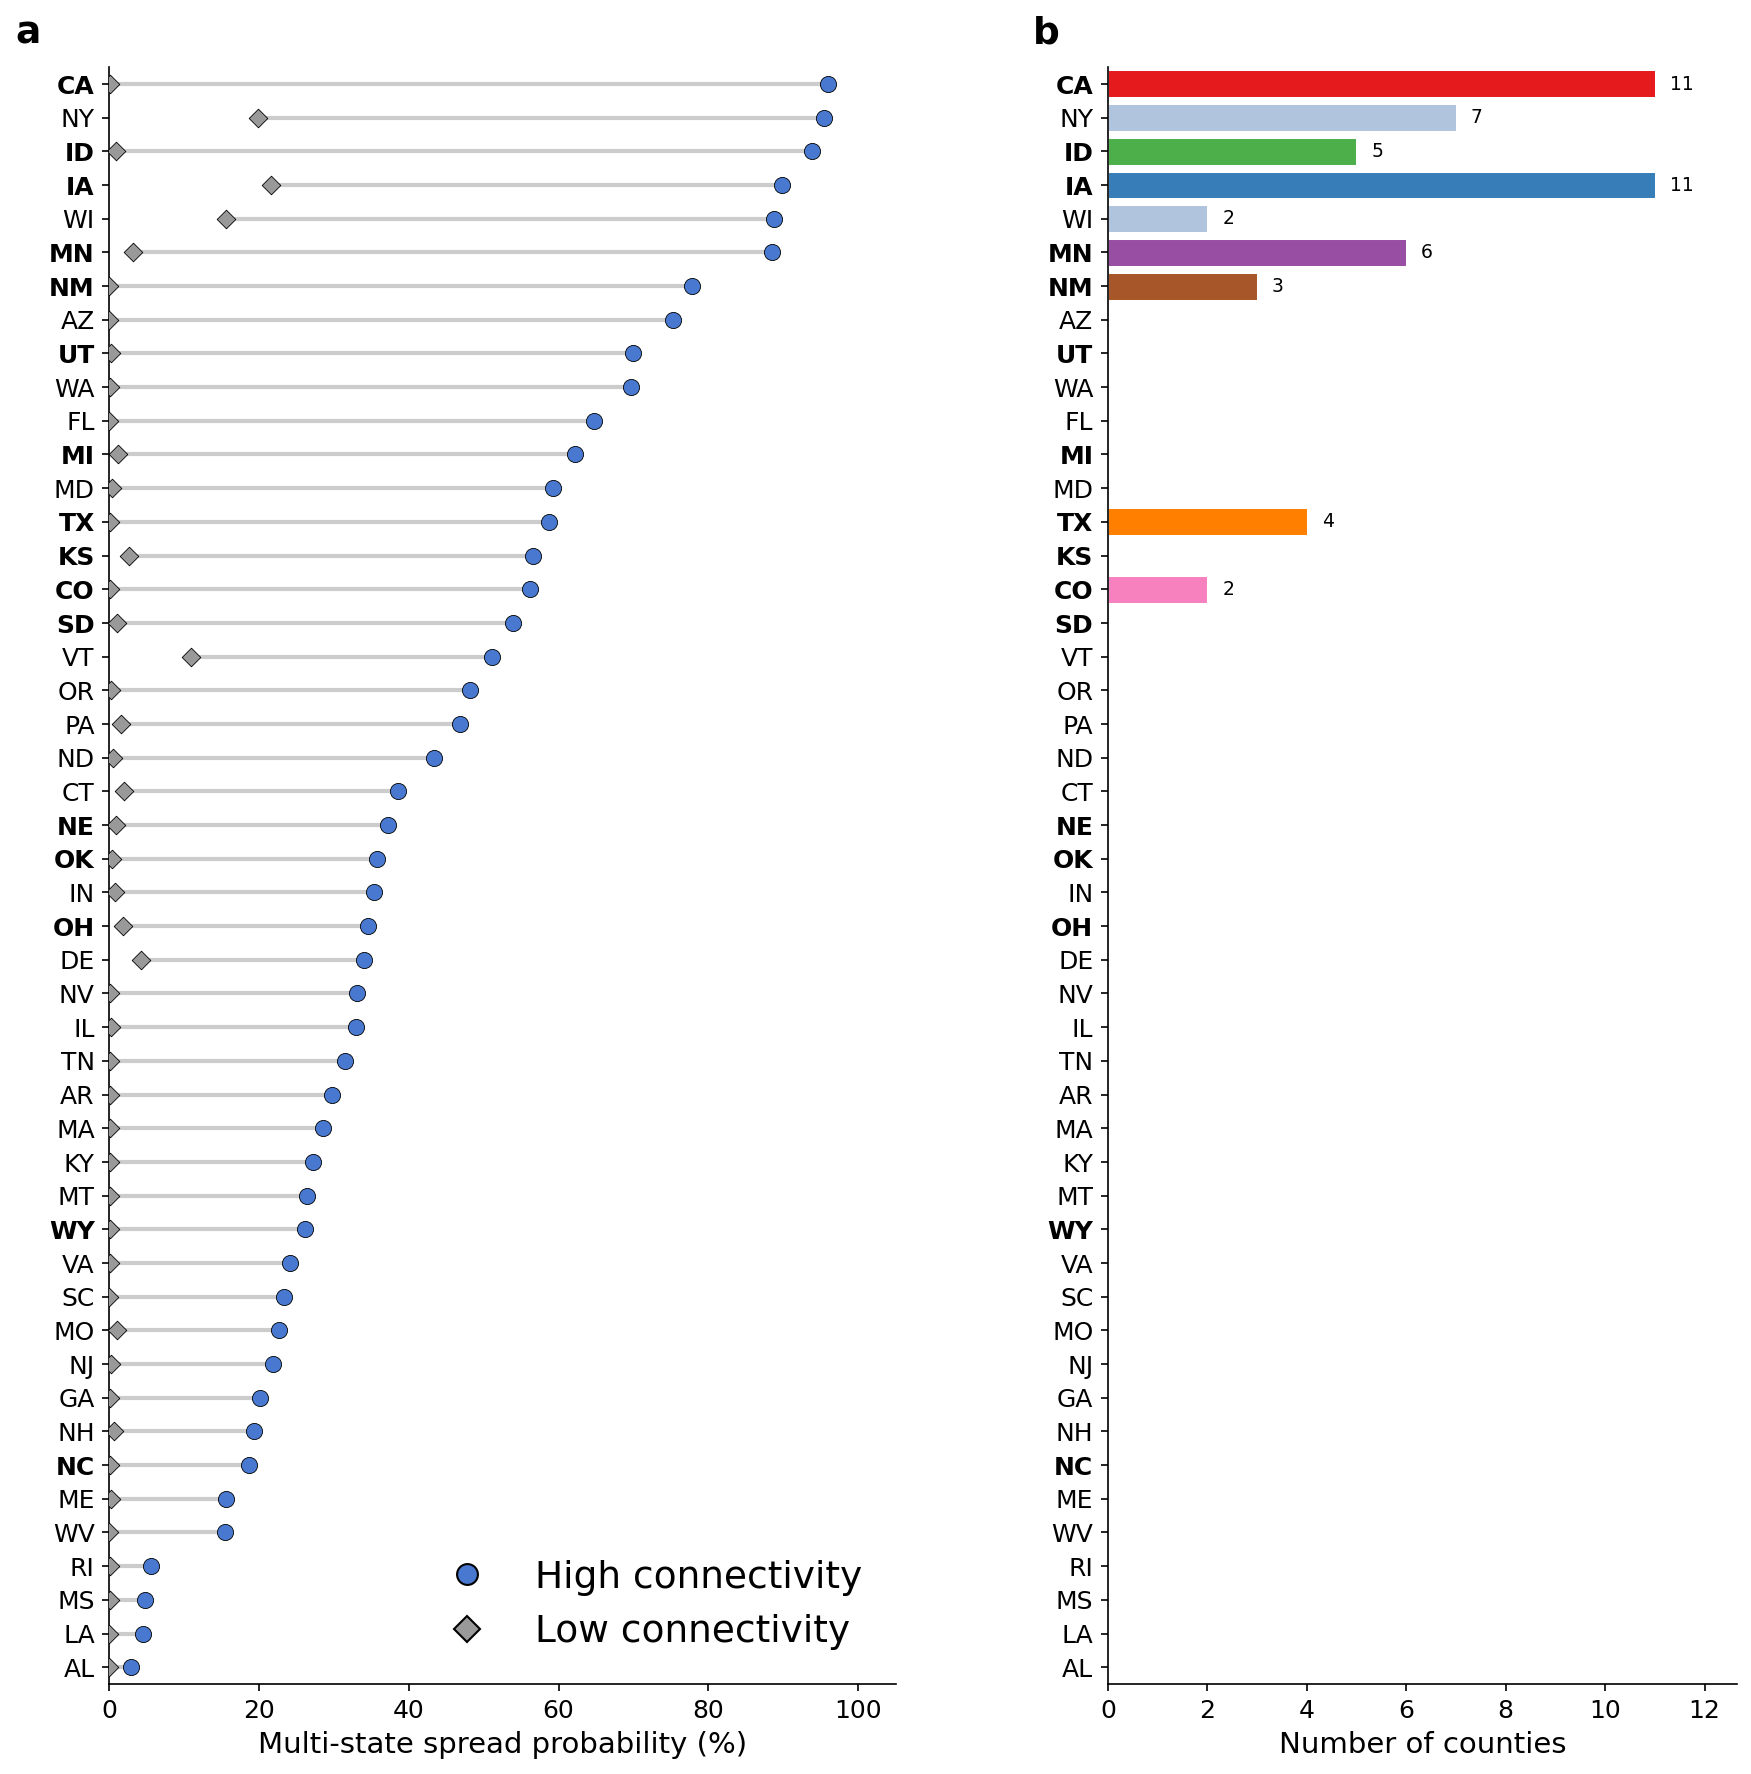

In [6]:
# ── Supplementary: All-48-states barbell + barplot ──

# Derive connectivity tiers from out-degree quartiles within each state
# For states with exactly 3 counties, use rank-based thirds (bottom=low, mid, top=high)
def assign_tiers(group):
    group = group.copy()
    n = len(group)
    if n <= 3:
        ranked = group['out_degree'].rank(method='first').astype(int)
        group['tier_derived'] = 'mid'
        group.loc[ranked == 1, 'tier_derived'] = 'low'
        group.loc[ranked == n, 'tier_derived'] = 'high'
    else:
        q25 = group['out_degree'].quantile(0.25)
        q75 = group['out_degree'].quantile(0.75)
        group['tier_derived'] = 'mid'
        group.loc[group['out_degree'] >= q75, 'tier_derived'] = 'high'
        group.loc[group['out_degree'] <= q25, 'tier_derived'] = 'low'
    return group

allcounty_tiered = allcounty.groupby('seed_state', group_keys=False).apply(assign_tiers)

# No minimum county filter — all 48 states included
state_counts = allcounty_tiered.groupby('seed_state').size()
print(f'States included: {len(state_counts)} (smallest: {state_counts.min()} counties in {state_counts.idxmin()})')

# ── Panel A: Barbell (all states) ──
tier_all = allcounty_tiered.groupby(['seed_state', 'tier_derived'])['pct_establishment_3'].mean().unstack(fill_value=0)
tier_all = tier_all.sort_values('high', ascending=True)

n_states_all = len(tier_all)

fig_allstates, (ax_barbell, ax_barplot) = plt.subplots(1, 2, figsize=(14, 14),
                                                        gridspec_kw={'width_ratios': [1, 0.8], 'wspace': 0.3})

y_positions = np.arange(n_states_all)
for i, st in enumerate(tier_all.index):
    h_val = tier_all.loc[st, 'high'] if 'high' in tier_all.columns else 0
    l_val = tier_all.loc[st, 'low'] if 'low' in tier_all.columns else 0
    ax_barbell.plot([l_val, h_val], [i, i], '-', color='#CCCCCC', lw=2, zorder=1)
    ax_barbell.scatter(h_val, i, c='#4878CF', s=60, edgecolors='black', linewidths=0.4, zorder=5)
    ax_barbell.scatter(l_val, i, c='#999999', marker='D', s=40, edgecolors='black', linewidths=0.4, zorder=5)

ax_barbell.set_yticks(y_positions)
ytick_labels_a = []
for st in tier_all.index:
    ytick_labels_a.append(st)
ax_barbell.set_yticklabels(ytick_labels_a, fontsize=9)
for tick, st in zip(ax_barbell.get_yticklabels(), tier_all.index):
    if st in OUTBREAK_STATES:
        tick.set_fontweight('bold')
ax_barbell.set_ylim(-0.5, n_states_all - 0.5)
ax_barbell.set_xlim(0, 105)
ax_barbell.set_xlabel('Multi-state spread probability (%)', fontsize=14)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4878CF', markersize=10,
           markeredgecolor='black', label='High connectivity'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#999999', markersize=9,
           markeredgecolor='black', label='Low connectivity'),
]
ax_barbell.legend(handles=legend_elements, loc='lower right', fontsize=18, frameon=False)
style_ax(ax_barbell)

# ── Panel B: Barplot >=95% (ALL states from Panel A, ordered same as Panel A) ──
high95_counts_all = allcounty[allcounty['pct_establishment_3'] >= 95].groupby('seed_state').size()
high95_all = pd.DataFrame({
    'seed_state': tier_all.index,
    'count': [high95_counts_all.get(st, 0) for st in tier_all.index]
})

colors_bar = []
for s in high95_all['seed_state']:
    if s in STATE_COLORS:
        colors_bar.append(STATE_COLORS[s])
    else:
        colors_bar.append('#B0C4DE')

ax_barplot.barh(range(n_states_all), high95_all['count'],
                color=colors_bar, edgecolor='white', linewidth=0.5)
ax_barplot.set_yticks(range(n_states_all))
ax_barplot.set_yticklabels(high95_all['seed_state'], fontsize=9)
for tick, st in zip(ax_barplot.get_yticklabels(), high95_all['seed_state']):
    if st in OUTBREAK_STATES:
        tick.set_fontweight('bold')
ax_barplot.set_ylim(-0.5, n_states_all - 0.5)
ax_barplot.set_xlabel('Number of counties', fontsize=14)

for i, (_, row) in enumerate(high95_all.iterrows()):
    if row['count'] > 0:
        ax_barplot.text(row['count'] + 0.3, i, str(int(row['count'])), va='center', fontsize=9)
max_count = high95_all['count'].max()
ax_barplot.set_xlim(0, max_count * 1.15 if max_count > 0 else 10)
style_ax(ax_barplot)

# panel xlabel and ylabel fontsizes
ax_barbell.xaxis.label.set_fontsize(14)
ax_barbell.yaxis.label.set_fontsize(14)
ax_barplot.xaxis.label.set_fontsize(14)
ax_barplot.yaxis.label.set_fontsize(14)

# panel xtick and ytick fontsizes
ax_barbell.tick_params(labelsize=12)
ax_barplot.tick_params(labelsize=12)

# Panel labels
ax_barbell.text(-0.12, 1.01, 'a', transform=ax_barbell.transAxes, fontsize=18, fontweight='bold', va='bottom')
ax_barplot.text(-0.12, 1.01, 'b', transform=ax_barplot.transAxes, fontsize=18, fontweight='bold', va='bottom')

fig_allstates.savefig(FIG_DIR / 'S_AllStates_Establishment.png')
fig_allstates.savefig(FIG_DIR / 'S_AllStates_Establishment.pdf')
n_with_95 = (high95_all['count'] > 0).sum()
print(f'All-states supplement saved. {n_states_all} states in both panels')
print(f'States with >=95% counties: {n_with_95}')
print(f'Non-outbreak states with >=95%:')
non_outbreak_95 = high95_all[(high95_all['count'] > 0) & (~high95_all['seed_state'].isin(OUTBREAK_STATES))]
for _, r in non_outbreak_95.iterrows():
    print(f'  {r["seed_state"]}: {int(r["count"])} counties')
plt.show()